## Ensemble Learning

In [1]:
import numpy as np
import pandas as pd

load_df = pd.read_csv("data/force/f_train.csv")
drop_columns = ['RSHA', 'RMED', 'GR', 'PEF', 'SP', 'ROP', 'DRHO', 'RDEP', 'WELL']
load_df = load_df.drop(drop_columns, axis=1)
load_df = load_df.dropna()
df = load_df.copy()

# Categorize Lithology
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}
df["LITHOLOGY"] = df["LITHOLOGY"].map(litho_code)

df = df[df.LITHOLOGY != "Shale"]
df = df.reset_index(drop=True)

drop = ['GROUP', 'FORMATION', 'BS']
dt_df = df.drop(drop, axis=1)

# Select sample that Litho is in ['Limestone', 'SandstoneShale']
# dt_df = dt_df[dt_df["LITHOLOGY"].isin(["Limestone", "SandstoneShale"])]
dt_df = dt_df.reset_index(drop=True)
dtdfraw = dt_df.copy()
dt_df.head(10)

,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,1151.928,17.363323,2.000440,0.589035,133.393707,SandstoneShale
1,1152.080,17.306395,2.007255,0.595443,135.019684,SandstoneShale
2,1152.232,17.303955,2.017085,0.610448,136.660767,SandstoneShale
3,1152.384,17.368221,2.027622,0.614587,136.615814,SandstoneShale
4,1152.536,17.433296,2.033576,0.600994,134.936020,SandstoneShale
5,1159.376,17.332830,1.993782,0.633213,141.699799,SandstoneShale
6,1159.528,17.305010,1.981597,0.596889,141.424210,SandstoneShale
7,1160.440,17.648685,1.926005,0.550250,140.952103,SandstoneShale
8,1160.592,17.555012,1.899559,0.561272,142.641083,SandstoneShale
9,1168.344,17.534988,2.004711,0.587427,138.450134,SandstoneShale


In [2]:
# Train and Test Split
from sklearn.model_selection import train_test_split
X = dt_df.drop("LITHOLOGY", axis=1)
y = dt_df["LITHOLOGY"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
def plot_classification_report(report, title='Classification Report'):
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='Blues', fmt='.2f', cbar=False)
    plt.title(title)
    plt.xlabel('Metrics')
    plt.ylabel('Classes')
    plt.gca().xaxis.set_label_position('top')  # Move x-axis label to the top
    plt.gca().xaxis.tick_top()  # Move x-axis ticks to the top
    plt.show()

def plot_confusion_matrix(y_test, y_pred, labels, title='Confusion Matrix for SVM Model'):
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
    plt.show()

### Random Forest Classifier

Accuracy: ('Accuracy:', 0.9513416815742397)


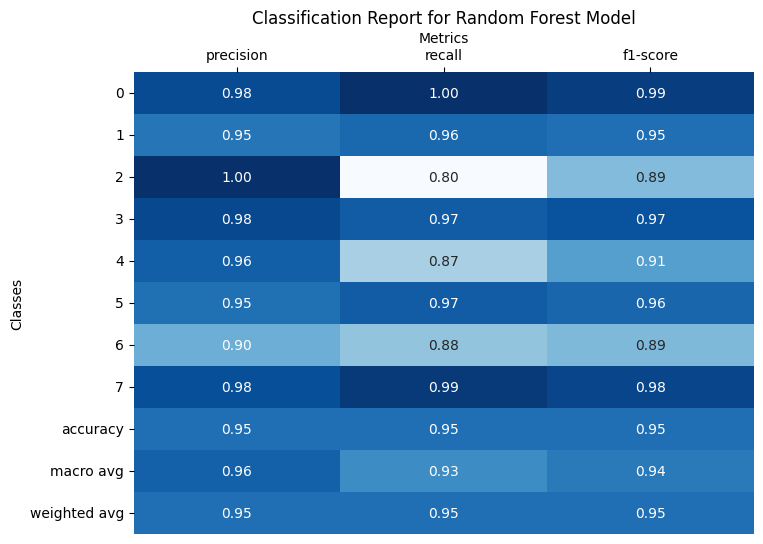

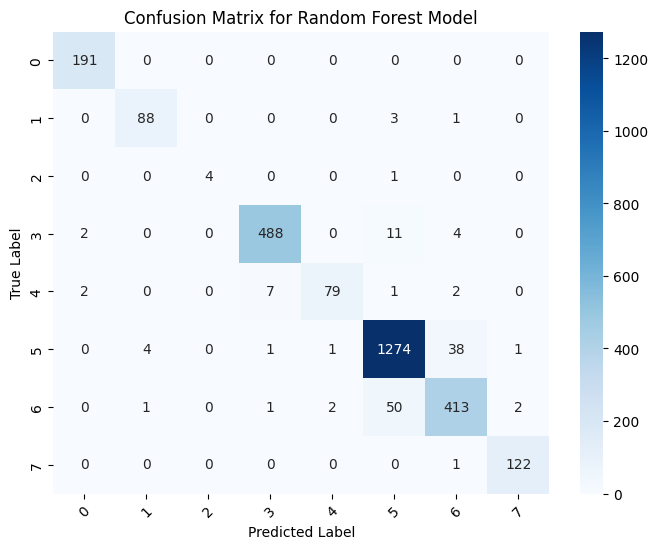

In [9]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# Evaluate the model
from sklearn.metrics import classification_report, accuracy_score
y_pred = rf.predict(X_test)
rf_acc = "Accuracy:", accuracy_score(y_test, y_pred)
print("Accuracy:", rf_acc)
report = classification_report(y_test, y_pred, output_dict=True)
plot_classification_report(report, title='Classification Report for Random Forest Model')
# Plot confusion matrix
plot_confusion_matrix(y_test, y_pred, labels=rf.classes_, title='Confusion Matrix for Random Forest Model')

### Light GBM Classifier

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 11177, number of used features: 5
[LightGBM] [Info] Start training from score -2.697548
[LightGBM] [Info] Start training from score -3.310346
[LightGBM] [Info] Start training from score -5.855877
[LightGBM] [Info] Start training from score -1.711751
[LightGBM] [Info] Start training from score -3.384077
[LightGBM] [Info] Start training from score -0.783638
[LightGBM] [Info] Start training from score -1.763097
[LightGBM] [Info] Start training from score -2.984788
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

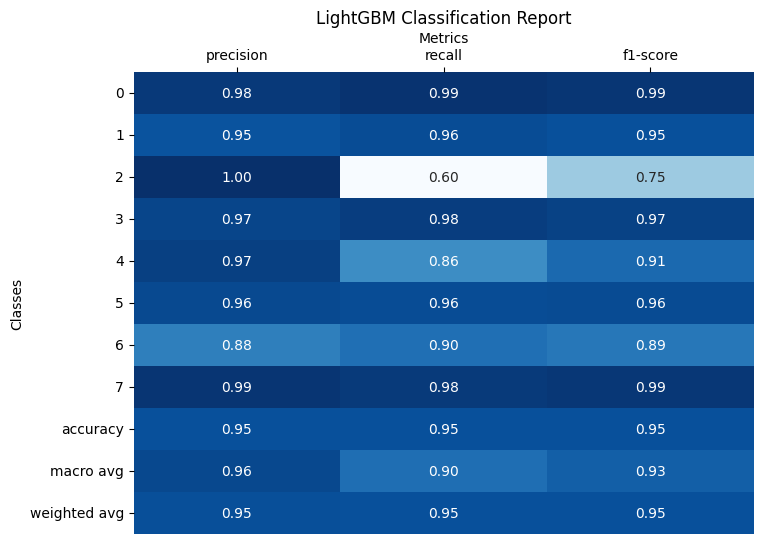

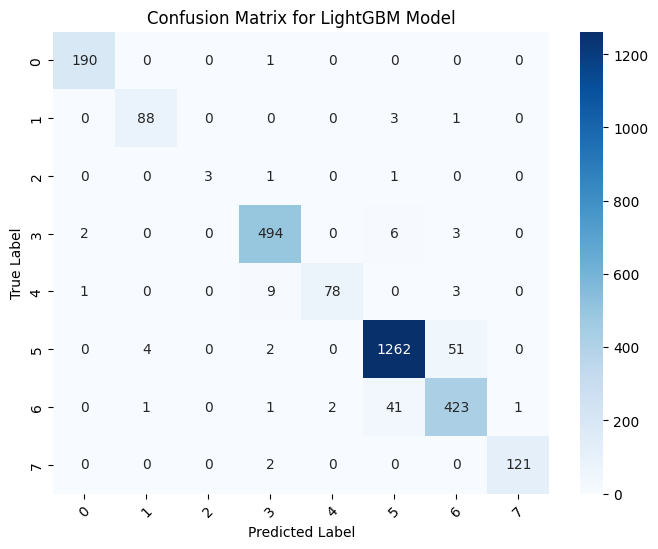

In [10]:
# Light GBM Classifier
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)
# Evaluate the model
y_pred_lgbm = lgbm.predict(X_test)
lgbm_acc = "LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm)
print("LightGBM Accuracy:", lgbm_acc)
report_lgbm = classification_report(y_test, y_pred_lgbm, output_dict=True)
plot_classification_report(report_lgbm, title='LightGBM Classification Report')
# Plot confusion matrix for LightGBM
plot_confusion_matrix(y_test, y_pred_lgbm, labels=lgbm.classes_, title='Confusion Matrix for LightGBM Model')

### XGBoost Classifier

XGBoost Accuracy: ('XGBoost Accuracy:', 0.9491949910554561)


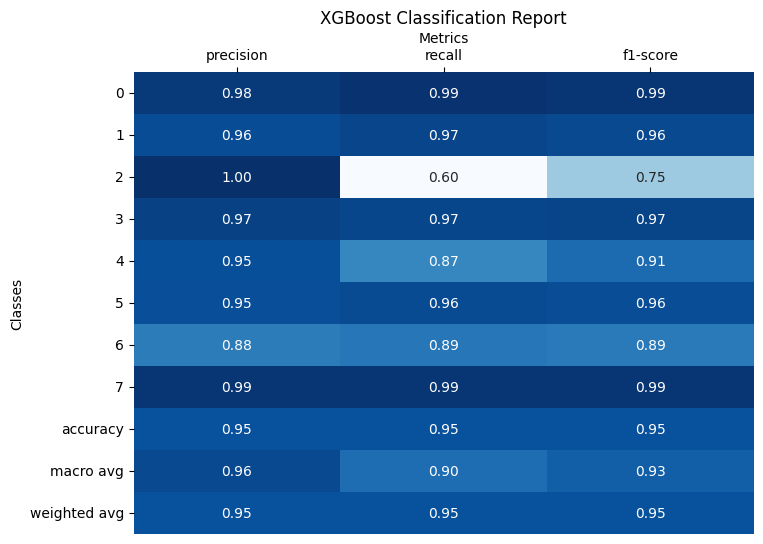

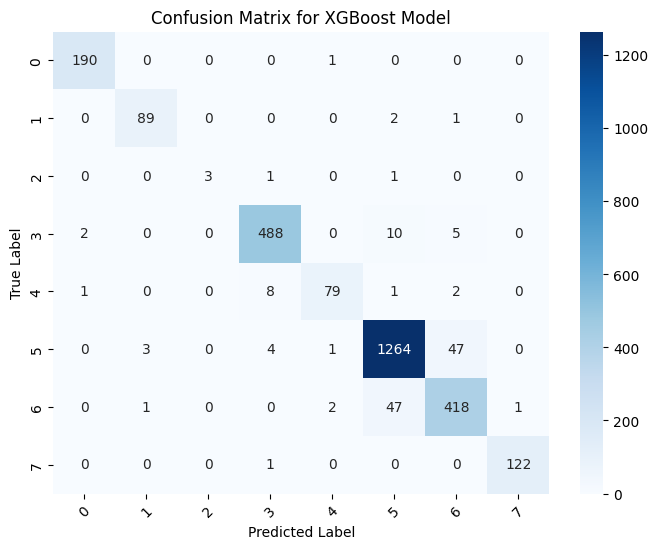

In [11]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

le = LabelEncoder()
dt_df_2 = dt_df.copy()
dt_df_2["LITHOLOGY"] = le.fit_transform(dt_df_2["LITHOLOGY"])

# Train and Test Split for XGBoost
X = dt_df_2.drop("LITHOLOGY", axis=1)
y = dt_df_2["LITHOLOGY"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost Classifier
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# Predict using XGBoost
y_pred_xgb = xgb.predict(X_test)

# Evaluate the model
xgb_acc = "XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", xgb_acc)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
plot_classification_report(report_xgb, title='XGBoost Classification Report')
# Plot confusion matrix for XGBoost
plot_confusion_matrix(y_test, y_pred_xgb, labels=xgb.classes_, title='Confusion Matrix for XGBoost Model')

### Accuracies comparison

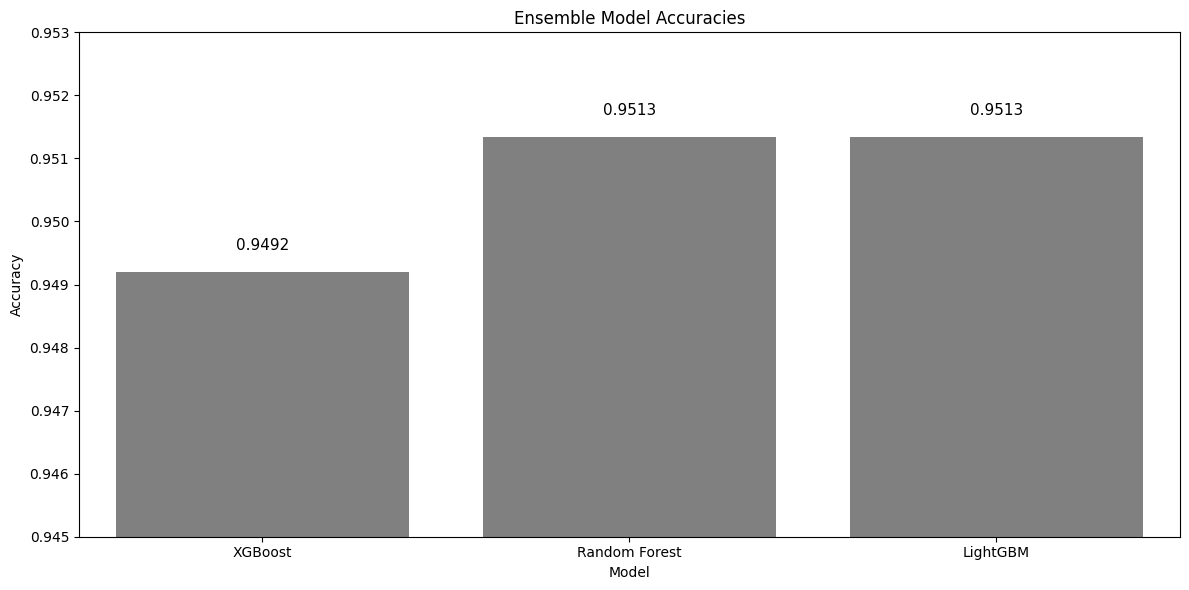

In [32]:
accuracies = {
    "XGBoost": xgb_acc[1],
    "Random Forest": rf_acc[1],
    "LightGBM": lgbm_acc[1],
}
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), color='gray', alpha=1)
plt.title('Ensemble Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.945, .953)  

# Add value to top of the bar
for i, value in enumerate(accuracies.values()):
    plt.text(i, value + 0.0003, f'{value:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()